<a href="https://colab.research.google.com/github/LetheeshBalaji/24ADI003-24BAD063/blob/main/heart_stacking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

**Load Dataset**

In [9]:
df = pd.read_csv("/heart_stacking.csv")

df.head()


,Age,Cholesterol,MaxHeartRate,RestingBP,HeartDisease
0,57,212,189,118,0
1,44,266,155,146,1
2,59,279,168,128,1
3,66,237,123,145,1
4,58,221,125,132,0


**Data Preprocessing**

In [10]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           120 non-null    int64
 1   Cholesterol   120 non-null    int64
 2   MaxHeartRate  120 non-null    int64
 3   RestingBP     120 non-null    int64
 4   HeartDisease  120 non-null    int64
dtypes: int64(5)
memory usage: 4.8 KB


In [11]:

df["HeartDisease"].value_counts()

,count
HeartDisease,
1,83
0,37


In [12]:

X = df[["Cholesterol","MaxHeartRate","Age"]]   # required features
y = df["HeartDisease"]

In [13]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Train Individual Models**

In [14]:
dt = DecisionTreeClassifier(max_depth=3)
lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True, C=1.0)

In [15]:

lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [16]:
lr_pred = lr.predict(X_test)
svm_pred = svm.predict(X_test)
dt_pred = dt.predict(X_test)

In [17]:

lr_acc = accuracy_score(y_test, lr_pred)
svm_acc = accuracy_score(y_test, svm_pred)
dt_acc = accuracy_score(y_test, dt_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("SVM Accuracy:", svm_acc)
print("Decision Tree Accuracy:", dt_acc)

Logistic Regression Accuracy: 0.7083333333333334
SVM Accuracy: 0.7916666666666666
Decision Tree Accuracy: 0.6666666666666666


**Apply Stacking Classifier**

In [18]:

estimators = [
    ('lr', LogisticRegression()),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier(max_depth=4))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)

print("Stacking Accuracy:", stack_acc)

Stacking Accuracy: 0.6666666666666666


**Model Comparison**

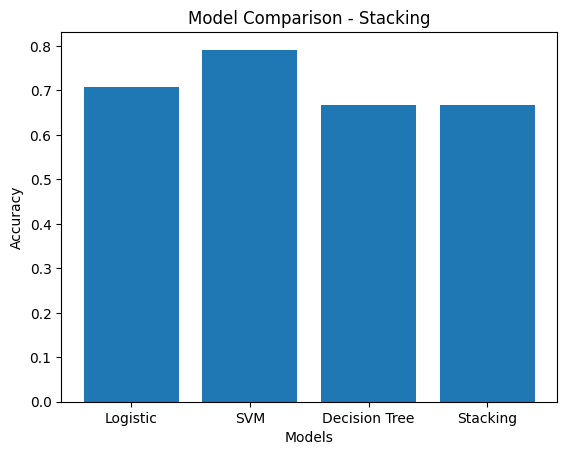

In [19]:
models = ["Logistic", "SVM", "Decision Tree", "Stacking"]
accuracies = [lr_acc, svm_acc, dt_acc, stack_acc]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Stacking")
plt.show()

Import Required Libraries